In [12]:
import matplotlib.pyplot as plt
from gerrychain import (Partition, Graph, MarkovChain,
                        updaters, constraints, accept,
                        GeographicPartition)
from gerrychain.proposals import recom
from gerrychain.tree import bipartition_tree
from gerrychain.constraints import contiguous
from functools import partial
import maup
import geopandas

# Set the random seed so that the results are reproducible!
import random
random.seed(42)

AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.

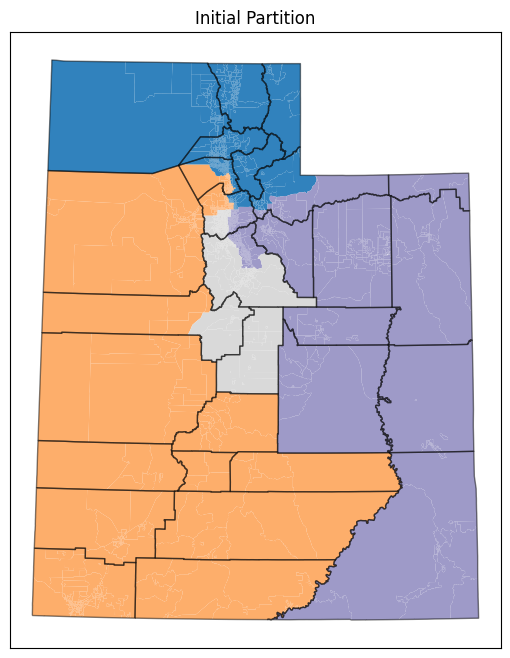

In [ ]:
districts = geopandas.read_file("plans/CONG/ut_cong_2021/ut_cong_2021.shp")
blocks = geopandas.read_file("data/UT_precincts.geojson")

districts.to_crs(blocks.crs, inplace=True)

blocks["CONGDIST"] = maup.assign(blocks, districts)

graph = Graph.from_geodataframe(blocks)

my_updaters = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": updaters.cut_edges,
    "perimeter": updaters.perimeter,
    "area": updaters.Tally("area", alias="area"),
}

initial_partition = GeographicPartition(
    graph,
    assignment="CONGDIST",
    updaters=my_updaters
)
counties = geopandas.read_file("data/cois/UtahCountyBoundaries/ut_cnty_2020_bound.shp")
counties.to_crs(blocks.crs, inplace=True)

fig, ax = plt.subplots(figsize=(8,8))
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Initial Partition")
initial_partition.plot(ax=ax, cmap='tab20c')
counties.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.5)


In [ ]:
munis = geopandas.read_file("data/cois/UtahMunicipalBoundaries/Municipalities.shp")
munis.to_crs(blocks.crs, inplace=True)

def count_muni_splits(partition, blocks):
    assigned = blocks.copy()
    assigned['district'] = assigned.index.map(partition.assignment)

    # Use maup to assign municipalities to districts
    muni_to_districts = maup.assign(munis, assigned)

    muni_splits = 0
    for muni_id in munis.index:
        districts = muni_to_districts[muni_id]
        if isinstance(districts, list) and len(districts) > 1:
            muni_splits += 1

    return muni_splits

count_muni_splits(initial_partition, blocks)

0

In [11]:
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)

proposal = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_population,
    epsilon=0.001,
    node_repeats=2,
    region_surcharge={
        "MUNIID": 5,
        "COUNTYID": 4
    },
    # method = partial(
    #     bipartition_tree,
    #     max_attempts=100,
    #     allow_pair_reselection=True,
    # )
)

recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=20,
)

%matplotlib inline
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')

import pandas as pd

import matplotlib.cm as mcm
import matplotlib.pyplot as plt
import networkx as nx
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

frames = []
district_data = []

for i, partition in enumerate(recom_chain.with_progress_bar()):
    for district_name in partition.perimeter.keys():
        population = partition.population[district_name]
        perimeter = partition.perimeter[district_name]
        area = partition.area[district_name]
        district_data.append((i, district_name, population, perimeter, area))

    buffer = io.BytesIO()
    fig, ax = plt.subplots(figsize=(10,10))
    partition.plot(ax=ax, cmap='tab20c')
    counties.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(buffer, format='png', bbox_inches='tight')
    buffer.seek(0)
    image = Image.open(buffer)
    frames.append(image)
    plt.close(fig)

df = pd.DataFrame(
    district_data,
    columns=[
        'step',
        'district_name',
        'population',
        'perimeter',
        'area'
    ]
)

def show_frame(idx):
    clear_output(wait=True)
    display(frames[idx])

slider = widgets.IntSlider(value=0, min=0, max=len(frames)-1, step=1, description='Frame:')
slider.layout.width = '500px'
widgets.interactive(show_frame, idx=slider)

  0%|          | 0/20 [00:00<?, ?it/s]

interactive(children=(IntSlider(value=0, description='Frame:', layout=Layout(width='500px'), max=19), Output()…